# 05. Análisis de Resultados
## TFM — Estimación de Precios de la Electricidad y Arbitraje Energético
### Jaime Cremades Castelló | CUNEF Universidad | 2026

Este notebook integra y analiza los resultados de todos los modelos en tres etapas:

1. **Unificación de predicciones** — alineación temporal de los CSV de predicciones de cada modelo
2. **Métricas predictivas** — cálculo de MAE, RMSE, MAPE y sMAPE para los siete modelos
3. **Visualización** — gráficos de predicción vs real, distribución de errores y evolución temporal del MAE

**Input:** `preds_*.csv`, `precios_reales_test.csv`, `resultados_arbitraje.csv`, `beneficios_diarios.csv`
**Output:** `predicciones_test.csv`, `tabla_metricas_final.csv`, gráficos PNG


---

# PARTE 1 — Unificación de predicciones

---

In [11]:
import pandas as pd

### Sarima

In [12]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_sarima.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_sarima.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime      SARIMA
0  2025-01-01 00:00:00  129.640520
1  2025-01-01 01:00:00  128.121608
2  2025-01-01 02:00:00  125.737754
3  2025-01-01 03:00:00  122.303925
4  2025-01-01 04:00:00  125.278675


### XGBoost

In [13]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_xgboost.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_xgboost.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime     XGBoost
0  2025-01-01 00:00:00  125.210762
1  2025-01-01 01:00:00  127.000938
2  2025-01-01 02:00:00  131.102356
3  2025-01-01 03:00:00  128.669235
4  2025-01-01 04:00:00  124.331032


### LSTM

In [14]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_lstm.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_lstm.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime       LSTM
0  2025-01-01 00:00:00  68.312057
1  2025-01-01 01:00:00  68.400665
2  2025-01-01 02:00:00  63.260113
3  2025-01-01 03:00:00  64.032242
4  2025-01-01 04:00:00  68.762268


### N-BEATS

In [15]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_nbeats.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_nbeats.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime    N-BEATS
0  2025-01-01 00:00:00  70.962761
1  2025-01-01 01:00:00  62.518166
2  2025-01-01 02:00:00  56.125744
3  2025-01-01 03:00:00  48.135277
4  2025-01-01 04:00:00  53.669384


### NBEATSx

In [16]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_nbeatsx.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_nbeatsx.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime    NBEATSx  y_real
0  2025-01-01 00:00:00  54.646820   69.50
1  2025-01-01 01:00:00  51.421413   59.97
2  2025-01-01 02:00:00  51.491936   53.00
3  2025-01-01 03:00:00  55.611919   59.52
4  2025-01-01 04:00:00  64.787361   70.20


### BiGRU-KAN

In [17]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_bigru_kan.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_bigru_kan.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime  BiGRU-KAN
0  2025-01-01 00:00:00  60.975548
1  2025-01-01 01:00:00  55.575832
2  2025-01-01 02:00:00  49.286201
3  2025-01-01 03:00:00  48.338951
4  2025-01-01 04:00:00  60.389534


### BNN

In [18]:
real = pd.read_csv('precios_reales_test.csv')
pred = pd.read_csv('preds_bnn.csv')
pred['datetime'] = real['datetime_test'].values[:len(pred)]
pred.to_csv('preds_bnn.csv', index=False, float_format='%.6f')
print(pred.head(5))

              datetime      BNN_mu   BNN_lower   BNN_upper
0  2025-01-01 00:00:00  118.260289   89.117647  147.402931
1  2025-01-01 01:00:00  133.205740  110.353861  156.057620
2  2025-01-01 02:00:00  116.807616   79.527600  154.087632
3  2025-01-01 03:00:00   91.878715   48.747828  135.009602
4  2025-01-01 04:00:00  107.744953   80.204212  135.285693


### UNIFICAR

In [19]:
real    = pd.read_csv('precios_reales_test.csv')
sarima  = pd.read_csv('preds_sarima.csv')
xgb     = pd.read_csv('preds_xgboost.csv')
lstm    = pd.read_csv('preds_lstm.csv')
nbeats  = pd.read_csv('preds_nbeats.csv')
nbeatsx = pd.read_csv('preds_nbeatsx.csv')
bigru   = pd.read_csv('preds_bigru_kan.csv')
bnn     = pd.read_csv('preds_bnn.csv')

print('real:   ', len(real))
print('sarima: ', len(sarima))
print('xgb:    ', len(xgb))
print('lstm:   ', len(lstm))
print('nbeats: ', len(nbeats))
print('nbeatsx:', len(nbeatsx))
print('bigru:  ', len(bigru))
print('bnn:    ', len(bnn))

real:    10071
sarima:  10056
xgb:     10071
lstm:    9888
nbeats:  9888
nbeatsx: 9888
bigru:   9888
bnn:     10071


In [20]:
real    = pd.read_csv('precios_reales_test.csv', parse_dates=['datetime_test'])
sarima  = pd.read_csv('preds_sarima.csv', parse_dates=['datetime'])
xgb     = pd.read_csv('preds_xgboost.csv', parse_dates=['datetime'])
lstm    = pd.read_csv('preds_lstm.csv', parse_dates=['datetime'])
nbeats  = pd.read_csv('preds_nbeats.csv', parse_dates=['datetime'])
nbeatsx = pd.read_csv('preds_nbeatsx.csv', parse_dates=['datetime'])
bigru   = pd.read_csv('preds_bigru_kan.csv', parse_dates=['datetime'])
bnn     = pd.read_csv('preds_bnn.csv', parse_dates=['datetime'])

# Fecha de inicio comun — la mas tardia de todos los modelos
fecha_inicio = max(
    sarima['datetime'].min(),
    xgb['datetime'].min(),
    lstm['datetime'].min(),
    nbeats['datetime'].min(),
    nbeatsx['datetime'].min(),
    bigru['datetime'].min(),
    bnn['datetime'].min()
)
print('Fecha inicio comun:', fecha_inicio)

# Filtrar todos desde esa fecha
real    = real[real['datetime_test'] >= fecha_inicio].reset_index(drop=True)
sarima  = sarima[sarima['datetime'] >= fecha_inicio].reset_index(drop=True)
xgb     = xgb[xgb['datetime'] >= fecha_inicio].reset_index(drop=True)
lstm    = lstm[lstm['datetime'] >= fecha_inicio].reset_index(drop=True)
nbeats  = nbeats[nbeats['datetime'] >= fecha_inicio].reset_index(drop=True)
nbeatsx = nbeatsx[nbeatsx['datetime'] >= fecha_inicio].reset_index(drop=True)
bigru   = bigru[bigru['datetime'] >= fecha_inicio].reset_index(drop=True)
bnn     = bnn[bnn['datetime'] >= fecha_inicio].reset_index(drop=True)

print('Longitudes tras filtro:')
print('real:', len(real), '| sarima:', len(sarima), '| xgb:', len(xgb),
      '| lstm:', len(lstm), '| nbeats:', len(nbeats), '| nbeatsx:', len(nbeatsx),
      '| bigru:', len(bigru), '| bnn:', len(bnn))

n = min(len(real), len(sarima), len(xgb), len(lstm), len(nbeats),
        len(nbeatsx), len(bigru), len(bnn))

df = pd.DataFrame({
    'datetime_test': real['datetime_test'].values[:n],
    'precio_real':   real.iloc[:n, 1].values,
    'SARIMA':        sarima['SARIMA'].values[:n],
    'XGBoost':       xgb['XGBoost'].values[:n],
    'LSTM':          lstm['LSTM'].values[:n],
    'N-BEATS':       nbeats['N-BEATS'].values[:n],
    'NBEATSx':       nbeatsx['NBEATSx'].values[:n],
    'BiGRU-KAN':     bigru['BiGRU-KAN'].values[:n],
    'BNN_mu':        bnn['BNN_mu'].values[:n],
    'BNN_lower':     bnn['BNN_lower'].values[:n],
    'BNN_upper':     bnn['BNN_upper'].values[:n]
})

df.to_csv('predicciones_test.csv', index=False, float_format='%.6f')
print('\npredicciones_test.csv creado:', df.shape)
print(df.head())

Fecha inicio comun: 2025-01-01 00:00:00
Longitudes tras filtro:
real: 10071 | sarima: 10056 | xgb: 10071 | lstm: 9888 | nbeats: 9888 | nbeatsx: 9888 | bigru: 9888 | bnn: 10071

predicciones_test.csv creado: (9888, 11)
        datetime_test  precio_real      SARIMA     XGBoost       LSTM  \
0 2025-01-01 00:00:00       131.59  129.640520  125.210762  68.312057   
1 2025-01-01 01:00:00       131.49  128.121608  127.000938  68.400665   
2 2025-01-01 02:00:00       131.42  125.737754  131.102356  63.260113   
3 2025-01-01 03:00:00       120.49  122.303925  128.669235  64.032242   
4 2025-01-01 04:00:00       112.30  125.278675  124.331032  68.762268   

     N-BEATS    NBEATSx  BiGRU-KAN      BNN_mu   BNN_lower   BNN_upper  
0  70.962761  54.646820  60.975548  118.260289   89.117647  147.402931  
1  62.518166  51.421413  55.575832  133.205740  110.353861  156.057620  
2  56.125744  51.491936  49.286201  116.807616   79.527600  154.087632  
3  48.135277  55.611919  48.338951   91.878715   48

---

# PARTE 2 — Métricas predictivas

---

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('predicciones_test.csv', parse_dates=['datetime_test'])

y_real = df['precio_real'].values

MODELOS = {
    'SARIMA':    'SARIMA',
    'XGBoost':   'XGBoost',
    'LSTM':      'LSTM',
    'N-BEATS':   'N-BEATS',
    'NBEATSx':   'NBEATSx',
    'BiGRU-KAN': 'BiGRU-KAN',
    'BNN':       'BNN_mu'
}

def calcular_metricas(y_real, y_pred):
    mae  = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred)**2))
    # MAPE solo sobre horas con precio absoluto > 10 EUR/MWh
    mask = np.abs(y_real) > 10
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    # sMAPE — simetrico, estable con precios negativos y cercanos a cero
    smape = 100 * np.mean(2 * np.abs(y_real - y_pred) / (np.abs(y_real) + np.abs(y_pred)))
    return mae, rmse, mape, smape

rows = []
for nombre, col in MODELOS.items():
    if col in df.columns:
        mae, rmse, mape, smape = calcular_metricas(y_real, df[col].values)
        rows.append({
            'Modelo': nombre,
            'MAE (EUR/MWh)': round(mae, 4),
            'RMSE (EUR/MWh)': round(rmse, 4),
            'MAPE (%)': round(mape, 4),
            'sMAPE (%)': round(smape, 4)
        })

tabla = pd.DataFrame(rows).set_index('Modelo')
print(tabla.to_string())
tabla.to_csv('tabla_metricas_final.csv')
print('\nGuardado como tabla_metricas_final.csv')

           MAE (EUR/MWh)  RMSE (EUR/MWh)  MAPE (%)  sMAPE (%)
Modelo                                                       
SARIMA           19.8891         28.0527   40.1531    61.5489
XGBoost           7.7191         11.5395   15.4867    37.3257
LSTM             33.1358         41.8881   68.7626    70.8000
N-BEATS          28.8851         36.4748   56.2152    69.7206
NBEATSx          29.8953         40.5858   60.0224    75.6335
BiGRU-KAN        31.2293         39.7953   61.7218    72.3203
BNN              12.6205         16.0449   25.2875    48.2761

Guardado como tabla_metricas_final.csv


In [5]:
import pandas as pd
import numpy as np

def calcular_metricas(y_real, y_pred, nombre):
    mae   = np.mean(np.abs(y_real - y_pred))
    rmse  = np.sqrt(np.mean((y_real - y_pred)**2))
    mask  = np.abs(y_real) > 10
    mape  = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    smape = 100 * np.mean(2 * np.abs(y_real - y_pred) / (np.abs(y_real) + np.abs(y_pred)))
    print(f'{nombre}:')
    print(f'  MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.4f}% | sMAPE={smape:.4f}%')
    print(f'  Registros: {len(y_real)}')

df_pt = pd.read_csv('preds_nbeatsx.csv')
df_nf = pd.read_csv('preds_nbeatsx-nf.csv')

calcular_metricas(df_pt['y_real'].values, df_pt['NBEATSx'].values, 'NBEATSx PyTorch')
calcular_metricas(df_nf['y_real'].values, df_nf['NBEATSx'].values, 'NBEATSx NeuralForecast')

NBEATSx PyTorch:
  MAE=9.8016 | RMSE=12.7230 | MAPE=19.8716% | sMAPE=45.4186%
  Registros: 9888
NBEATSx NeuralForecast:
  MAE=24.3480 | RMSE=33.0315 | MAPE=47.4834% | sMAPE=67.2379%
  Registros: 10056


---

# PARTE 3 — Visualización de resultados

---

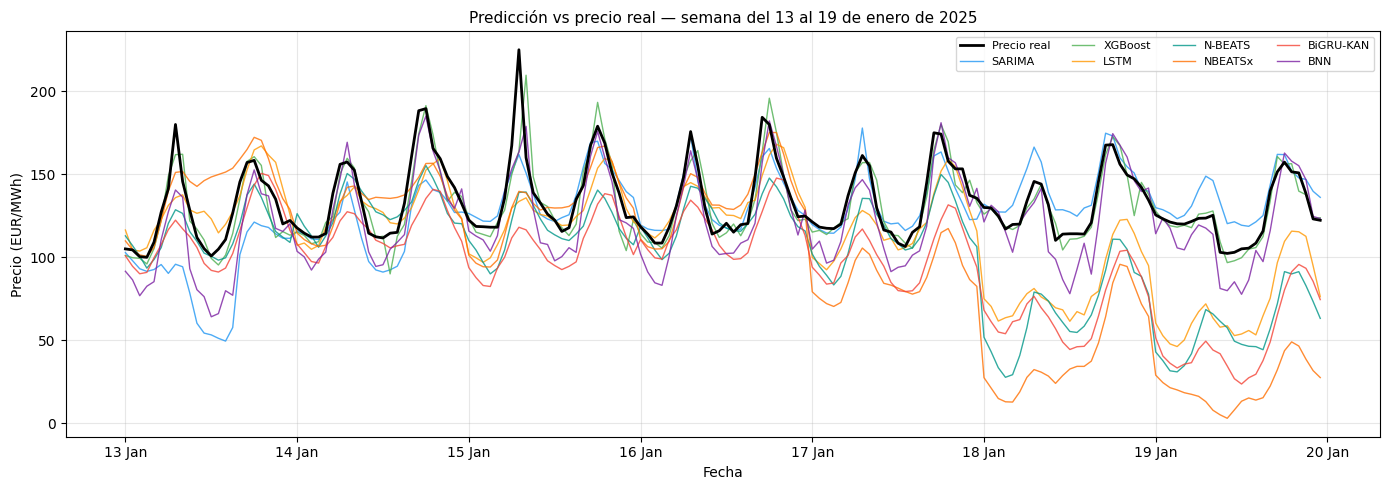

Gráfico 16 guardado


C:\Users\Jaime Cremades\AppData\Local\Temp\ipykernel_18996\4164646078.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errores, labels=NOMBRES, patch_artist=True,


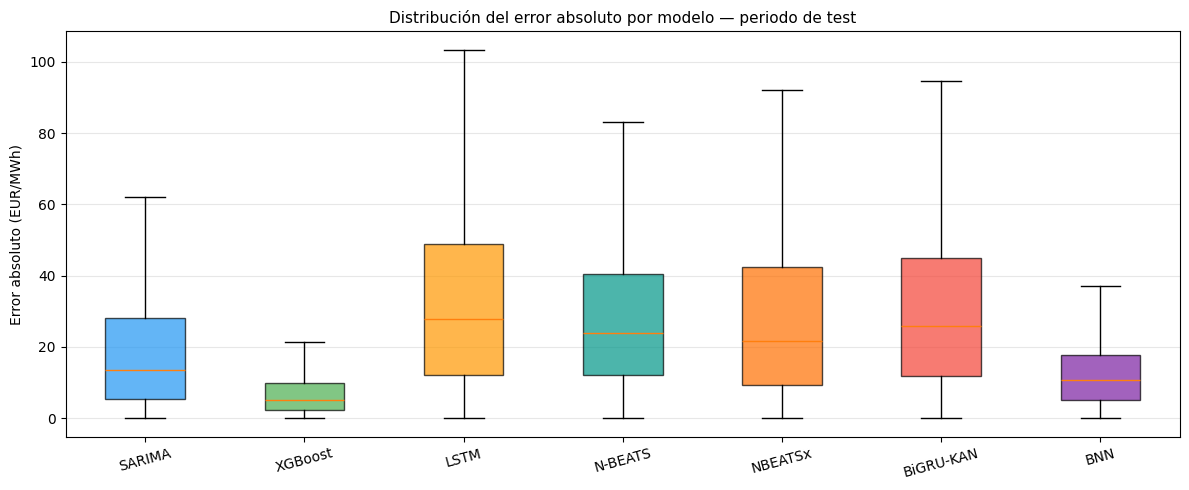

Gráfico 17 guardado


C:\Users\Jaime Cremades\AppData\Local\Temp\ipykernel_18996\4164646078.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_diario = df.groupby('fecha').apply(
C:\Users\Jaime Cremades\AppData\Local\Temp\ipykernel_18996\4164646078.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_diario = df.groupby('fecha').apply(
C:\Users\Jaime Cremades\AppData\Local\Temp\ipykernel_18996\4164646078.py:71: FutureWarning: Da

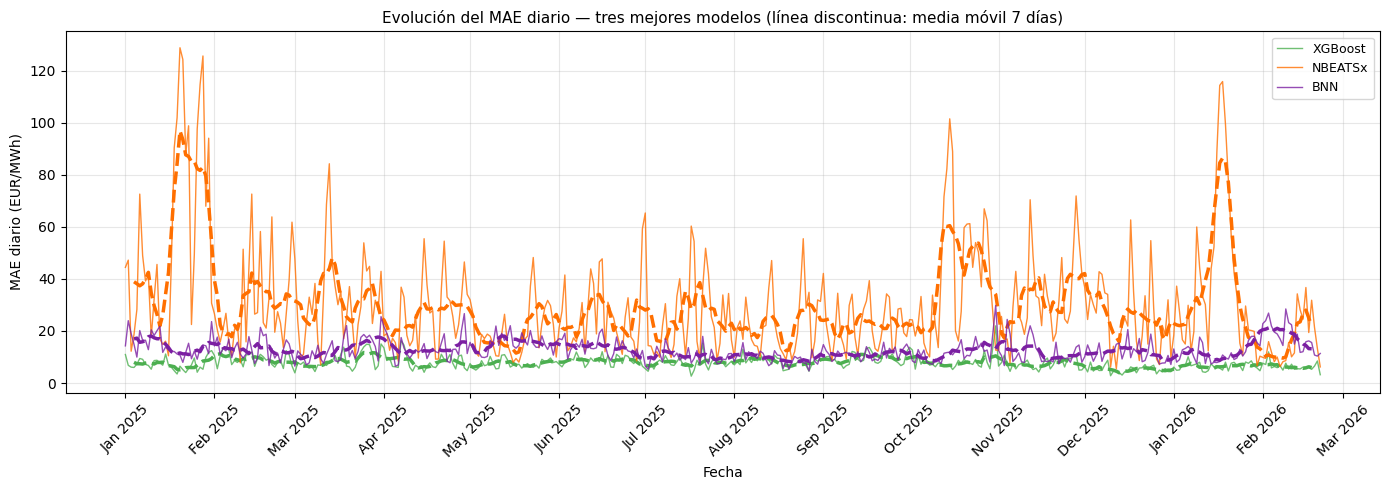

Gráfico 18 guardado


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('predicciones_test.csv', parse_dates=['datetime_test'])

MODELOS = ['SARIMA', 'XGBoost', 'LSTM', 'N-BEATS', 'NBEATSx', 'BiGRU-KAN', 'BNN_mu']
NOMBRES = ['SARIMA', 'XGBoost', 'LSTM', 'N-BEATS', 'NBEATSx', 'BiGRU-KAN', 'BNN']
COLORES = ['#2196F3', '#4CAF50', '#FF9800', '#009688', '#FF6F00', '#F44336', '#7B1FA2']

# ── GRÁFICO 16 — Predicción vs real una semana representativa ─────────────────
semana = df[(df['datetime_test'] >= '2025-01-13') & 
            (df['datetime_test'] < '2025-01-20')].copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(semana['datetime_test'], semana['precio_real'],
        color='black', linewidth=2, label='Precio real', zorder=5)

for col, nombre, color in zip(MODELOS, NOMBRES, COLORES):
    ax.plot(semana['datetime_test'], semana[col],
            color=color, linewidth=1, alpha=0.8, label=nombre)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.set_xlabel('Fecha', fontsize=10)
ax.set_ylabel('Precio (EUR/MWh)', fontsize=10)
ax.set_title('Predicción vs precio real — semana del 13 al 19 de enero de 2025', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_16_prediccion_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 16 guardado')

# ── GRÁFICO 17 — Boxplot del error absoluto por modelo ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

errores = []
for col in MODELOS:
    err = np.abs(df['precio_real'].values - df[col].values)
    errores.append(err)

bp = ax.boxplot(errores, labels=NOMBRES, patch_artist=True,
                showfliers=False, whis=1.5)

for patch, color in zip(bp['boxes'], COLORES):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Error absoluto (EUR/MWh)', fontsize=10)
ax.set_title('Distribución del error absoluto por modelo — periodo de test', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('grafico_17_boxplot_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 17 guardado')

# ── GRÁFICO 18 — MAE diario de los 3 mejores modelos ────────────────────────
df['fecha'] = df['datetime_test'].dt.date
mejores = {'XGBoost': '#4CAF50', 'NBEATSx': '#FF6F00', 'BNN_mu': '#7B1FA2'}
nombres_mejores = {'XGBoost': 'XGBoost', 'NBEATSx': 'NBEATSx', 'BNN_mu': 'BNN'}

fig, ax = plt.subplots(figsize=(14, 5))

for col, color in mejores.items():
    mae_diario = df.groupby('fecha').apply(
        lambda x: np.mean(np.abs(x['precio_real'].values - x[col].values))
    ).reset_index()
    mae_diario.columns = ['fecha', 'mae']
    mae_diario['fecha'] = pd.to_datetime(mae_diario['fecha'])

    ax.plot(mae_diario['fecha'], mae_diario['mae'],
            color=color, linewidth=1, alpha=0.8, label=nombres_mejores[col])

    # Media movil 7 dias
    ax.plot(mae_diario['fecha'],
            mae_diario['mae'].rolling(7, center=True).mean(),
            color=color, linewidth=2.5, linestyle='--')

ax.set_xlabel('Fecha', fontsize=10)
ax.set_ylabel('MAE diario (EUR/MWh)', fontsize=10)
ax.set_title('Evolución del MAE diario — tres mejores modelos (línea discontinua: media móvil 7 días)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('grafico_18_mae_diario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 18 guardado')